In [4]:
import re
import pandas as pd
import numpy as np

Read in the csv files.

In [9]:
epoch_001_preds = pd.read_csv('../preds/20260304_140323/epoch_001_fold2.csv')

def _parse_score(s):
    if isinstance(s, float):
        return s
    m = re.search(r'[\d.]+', str(s))
    return float(m.group()) if m else float('nan')

epoch_001_preds['pred_score'] = epoch_001_preds['pred_score'].apply(_parse_score)
epoch_001_preds['true_score'] = epoch_001_preds['true_score'].apply(_parse_score)

What is the range, mean, and std of memorability scores after 1 epoch of training? 

In [10]:
print("True memorability score stats:")
print("  Min:", epoch_001_preds['true_score'].min())
print("  Max:", epoch_001_preds['true_score'].max())
print("  Mean:", epoch_001_preds['true_score'].mean())
print("  Std:", epoch_001_preds['true_score'].std())

print("Predicted memorability score stats after 1 epoch of training:")
print("  Min:", epoch_001_preds['pred_score'].min())
print("  Max:", epoch_001_preds['pred_score'].max())
print("  Mean:", epoch_001_preds['pred_score'].mean())
print("  Std:", epoch_001_preds['pred_score'].std())

True memorability score stats:
  Min: 0.305556
  Max: 1.0
  Mean: 0.755646290029404
  Std: 0.12372510064493171
Predicted memorability score stats after 1 epoch of training:
  Min: 0.7179115
  Max: 0.78589165
  Mean: 0.750618519708634
  Std: 0.009219889513360634


Read in the results from THINGS inference.

In [7]:
things_fold1 = pd.read_csv("../preds/inference/things_20260313_151142/things_summary.csv")
things_fold2 = pd.read_csv("../preds/inference/things_20260313_115616/things_summary.csv")
things_fold3 = pd.read_csv("../preds/inference/things_20260313_152710/things_summary.csv")
things_fold4 = pd.read_csv("../preds/inference/things_20260313_154651/things_summary.csv")
things_fold5 = pd.read_csv("../preds/inference/things_20260313_150223/things_summary.csv")

In [10]:
things_fold1_srcc = things_fold1['spearman_rho']
things_fold2_srcc = things_fold2['spearman_rho']
things_fold3_srcc = things_fold3['spearman_rho']
things_fold4_srcc = things_fold4['spearman_rho']
things_fold5_srcc = things_fold5['spearman_rho']

In [16]:
things_mean = np.mean([things_fold1_srcc, things_fold2_srcc, things_fold3_srcc, things_fold4_srcc, things_fold5_srcc])
print(things_mean)
things_std = np.std([things_fold1_srcc, things_fold2_srcc, things_fold3_srcc, things_fold4_srcc, things_fold5_srcc])
print(things_std)

0.29312123694360354
0.00207553218179435


In [2]:
memcat_fold1 = pd.read_csv("../preds/inference/memcat_20260313_151732/memcat_summary.csv")
memcat_fold2 = pd.read_csv("../preds/inference/memcat_20260313_161557/memcat_summary.csv")
memcat_fold3 = pd.read_csv("../preds/inference/memcat_20260313_152342/memcat_summary.csv")
memcat_fold4 = pd.read_csv("../preds/inference/memcat_20260313_155202/memcat_summary.csv")
memcat_fold5 = pd.read_csv("../preds/inference/memcat_20260313_152018/memcat_summary.csv")

In [4]:
memcat_fold1_srcc = memcat_fold1['spearman_rho']
memcat_fold2_srcc = memcat_fold2['spearman_rho']
memcat_fold3_srcc = memcat_fold3['spearman_rho']
memcat_fold4_srcc = memcat_fold4['spearman_rho']
memcat_fold5_srcc = memcat_fold5['spearman_rho']

In [5]:
memcat_mean = np.mean([memcat_fold1_srcc, memcat_fold2_srcc, memcat_fold3_srcc, memcat_fold4_srcc, memcat_fold5_srcc])
print(memcat_mean)
memcat_std = np.std([memcat_fold1_srcc, memcat_fold2_srcc, memcat_fold3_srcc, memcat_fold4_srcc, memcat_fold5_srcc])
print(memcat_std)

0.7119638247389166
0.0035480130042506042


In [5]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

train = pd.read_csv('../Data/lamem/lamem_train_1.csv')
val   = pd.read_csv('../Data/lamem/lamem_val_1.csv')
test  = pd.read_csv('../Data/lamem/lamem_test_1.csv')

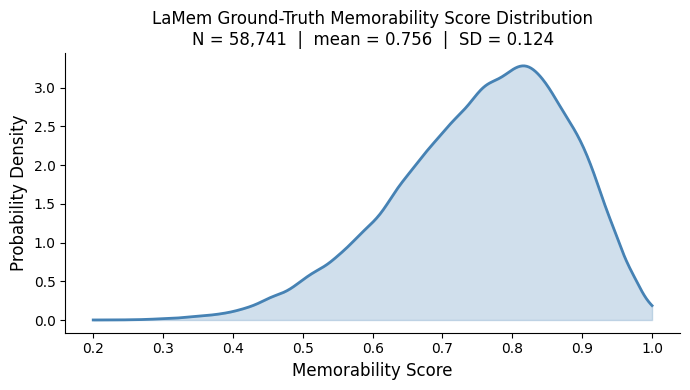

In [6]:
scores = pd.concat([train['score'], val['score'], test['score']], ignore_index=True).dropna()

kde = gaussian_kde(scores, bw_method='scott')
x = np.linspace(scores.min(), scores.max(), 500)
density = kde(x)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, density, color='steelblue', linewidth=2)
ax.fill_between(x, density, alpha=0.25, color='steelblue')
ax.set_xlabel('Memorability Score', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title(
    f'LaMem Ground-Truth Memorability Score Distribution\n'
    f'N = {len(scores):,}  |  mean = {scores.mean():.3f}  |  SD = {scores.std():.3f}',
    fontsize=12
)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [7]:
all_lamem = pd.concat([train, val, test], ignore_index=True)
all_lamem.to_csv("../Data/lamem/all_lamem.csv", index=False)
print(f"Saved {len(all_lamem)} rows to ../Data/lamem/all_lamem.csv")

Saved 58741 rows to ../Data/lamem/all_lamem.csv
